# Modèle d'utilisation des lignes de crédit renouvelables des petites entreprises

## Synthèse

Les lignes de crédit renouvelables sont engagées mais pas entièrement tirées : le **solde financé** d'un prêteur — et le capital économique qu'il doit détenir — dépend donc de la part de chaque ligne que l'emprunteur utilise réellement. Cette analyse modélise le **taux d'utilisation** (solde tiré / limite engagée) pour un échantillon de travail de **100 lignes renouvelables de petites entreprises** afin de prévoir l'exposition financée et d'appuyer la planification du capital.

Nous combinons quatre procédures SAS, chacune répondant à une question de planification distincte :

- **PROC MEANS** dresse le profil du solde tiré et de l'utilisation par **classe de risque** interne. L'utilisation moyenne augmente de façon monotone d'une classe à l'autre — 0,307 (A), 0,359 (B), 0,416 (C), 0,488 (D), 0,518 (E) — établissant la relation empirique entre qualité de crédit et usage qui alimente les hypothèses d'exposition en cas de défaut.
- **PROC REG** ajuste l'utilisation en fonction des fondamentaux de l'emprunteur (couverture du service de la dette, volatilité du chiffre d'affaires, ancienneté de la ligne, utilisation antérieure) et de l'environnement macroéconomique (chômage, taux court). Le modèle explique 45 % de la variance (R-Square 0,448, F p < .0001), et les estimations standardisées classent la **couverture du service de la dette** (-0,45) et l'**utilisation antérieure** (0,41) comme les déterminants dominants. Tous les facteurs d'inflation de la variance restent inférieurs à 1,17, la colinéarité n'est donc pas préoccupante.
- **PROC GLM** teste si l'utilisation diffère selon le **segment sectoriel** après contrôle de ces déterminants, à l'aide des moyennes des moindres carrés ajustées par la méthode de Tukey. L'effet sectoriel est globalement à la limite de la significativité (F p = 0,060), mais le secteur **Construction** tire nettement plus que le **Commerce de détail** (p = 0,007) et la **Santé** (p = 0,024) une fois la qualité de l'emprunteur maintenue constante.
- **PROC UNIVARIATE** extrait les 2,5e et 97,5e centiles d'utilisation — une plage de **0,121 à 0,744** autour d'une moyenne de 0,404 — définissant le scénario plausible de tirage faible/élevé pour les tests de résistance et de capital économique.

Ensemble, ces résultats permettent à la banque de transformer un portefeuille statique de limites engagées en une **prévision prospective du solde financé** reposant sur des hypothèses défendables et auditables. L'échantillon de 100 lignes est la tranche que cet environnement exécute ; le même programme s'applique sans modification à un portefeuille de production complet.

## Sources de données

Le jeu de données est généré de façon synthétique à l'intérieur du notebook (aucun fichier externe, aucun réseau). Chaque ligne correspond à une ligne de crédit renouvelable de petite entreprise observée à un instant donné.

| Variable | Type | Description |
|----------|------|-------------|
| `id_ligne` | Num | Identifiant unique de la ligne de crédit |
| `classe_risque` | Char | Classe de risque interne (A meilleure … E plus faible) |
| `secteur` | Char | Segment sectoriel de l'emprunteur (Commerce de détail, Services, Construction, Fabrication, Santé) |
| `limite_engagee` | Num | Montant de la ligne de crédit engagée (en milliers $) |
| `anciennete_mois` | Num | Ancienneté de la ligne (mois depuis l'octroi) |
| `csd` | Num | Ratio de couverture du service de la dette |
| `volatilite_ca` | Num | Volatilité du chiffre d'affaires sur période glissante (coefficient de variation) |
| `util_anterieure` | Num | Taux d'utilisation de la période précédente (0–1) |
| `taux_chomage` | Num | Taux de chômage local (%) à la date d'observation |
| `taux_court` | Num | Taux de référence à court terme en vigueur (%) |
| `taux_utilisation` | Num | Solde tiré / limite engagée (0–1), la réponse modélisée |
| `solde_finance` | Num | Solde financé = utilization_rate × committed_limit (en milliers $) |

**Échelle :** l'étape DATA est écrite pour générer un portefeuille complet, mais cet environnement s'exécute sans licence et plafonne la sortie aux **100 premières lignes** — l'échantillon de travail analysé tout au long. Ces 100 lignes couvrent les 5 classes de risque (A–E) et les 5 segments sectoriels. L'utilisation est simulée à partir d'une variable latente à lien logit pilotée par les covariables ci-dessus plus du bruit, de sorte que la régression et le GLM retrouvent un signal véritable et interprétable. Le temps d'exécution est bien inférieur à 60 secondes.

## 1. Générer le portefeuille synthétique de lignes de crédit

La première cellule construit un portefeuille réaliste de lignes renouvelables de petites entreprises (cet environnement plafonne l'exécution aux **100 premières lignes**). Nous tirons une classe de risque et un segment sectoriel pour chaque ligne, puis simulons les fondamentaux de l'emprunteur et l'environnement macroéconomique. L'utilisation est générée à partir d'un **score latent à lien logit** de sorte que les classes plus faibles, une couverture du service de la dette plus basse, une volatilité du chiffre d'affaires plus élevée, une utilisation antérieure persistante et un contexte macroéconomique tendu poussent tous à la hausse la fraction tirée — exactement la structure que la régression et le GLM ci-dessous sont censés retrouver. Le solde financé `solde_finance` est alors l'utilisation multipliée par la limite engagée.

In [1]:
/* --------------------------------------------------------
   Génère un portefeuille synthétique de lignes de crédit
   renouvelables de petites entreprises. L'utilisation est
   simulée à partir d'une latente à lien logit pilotée par
   les covariables de crédit, d'emprunteur et macro, afin
   que les modèles ci-dessous retrouvent un signal réel.
   -------------------------------------------------------- */
DONNÉES lignes_credit;
    APPELER streaminit(20260605);

    ÉTIQUETTE id_ligne         = "Identifiant de la ligne de crédit"
          classe_risque    = "Classe de risque interne (A-E)"
          secteur          = "Segment sectoriel de l'emprunteur"
          limite_engagee   = "Limite engagée (k$)"
          anciennete_mois  = "Ancienneté de la ligne (mois)"
          csd              = "Ratio de couverture du service de la dette"
          volatilite_ca    = "Volatilité du chiffre d'affaires (CV)"
          util_anterieure  = "Taux d'utilisation antérieur"
          taux_chomage     = "Taux de chômage local (%)"
          taux_court       = "Taux de référence à court terme (%)"
          taux_utilisation = "Taux d'utilisation (tiré/limite)"
          solde_finance    = "Solde financé (k$)";

    /* Tableaux de correspondance pour attributs catégoriels */
    TABLEAU classes[5] $1 _temporary_ ('A' 'B' 'C' 'D' 'E');
    TABLEAU secteurs[5] $20 _temporary_
        ('Commerce de détail' 'Services' 'Construction'
         'Fabrication' 'Santé');

    FAIRE id_ligne = 1 JUSQU_À 4000;

        /* Classe de risque : plus de masse au centre */
        g = rand('TABLE', 0.15, 0.28, 0.30, 0.18, 0.09);
        classe_risque = classes[g];

        /* Segment sectoriel : réparti avec un biais détail */
        s = rand('TABLE', 0.28, 0.24, 0.18, 0.16, 0.14);
        secteur = secteurs[s];

        /* Limite engagée : log-normale, 25 k$ à ~1,5 M$ */
        limite_engagee = round(25 + EXP(rand('NORMAL', 4.6, 0.55)), 1);

        /* Fondamentaux de l'emprunteur */
        anciennete_mois = round(rand('UNIFORM') * 84 + 3, 1);
        csd             = round(0.8 + rand('GAMMA', 4) * 0.30, 0.01);
        volatilite_ca   = round(0.10 + rand('GAMMA', 2) * 0.07, 0.001);
        util_anterieure = MIN(0.98, MAX(0.02,
                             rand('BETA', 2, 3)));

        /* Environnement macro à la date d'observation */
        taux_chomage = round(rand('NORMAL', 5.2, 1.1), 0.1);
        SI taux_chomage < 2.5 ALORS taux_chomage = 2.5;
        taux_court = round(rand('NORMAL', 4.0, 0.8), 0.01);
        SI taux_court < 0 ALORS taux_court = 0;

        /* Indice de sévérité de classe : A=0 ... E=4 */
        severite_classe = g - 1;

        /* Score latent d'utilisation à lien logit.
           Classes plus faibles, CSD plus basse, volatilité
           plus élevée, usage antérieur persistant et stress
           macro relèvent tous l'utilisation. */
        eta = -0.60
              + 0.34 * severite_classe
              - 0.55 * (csd - 1.4)
              + 1.10 * (volatilite_ca - 0.24)
              + 1.80 * (util_anterieure - 0.45)
              + 0.16 * (taux_chomage - 5.2)
              + 0.07 * (taux_court - 4.0)
              - 0.004 * (anciennete_mois - 40);

        /* Décalages de segment sectoriel sur l'échelle latente */
        SÉLECTIONNER (secteur);
            QUAND ('Construction')        eta = eta + 0.30;
            QUAND ('Commerce de détail')  eta = eta + 0.12;
            QUAND ('Fabrication')         eta = eta - 0.08;
            QUAND ('Santé')               eta = eta - 0.22;
            AUTREMENT; /* Services = référence */
        FIN;

        /* Bruit, puis passage vers (0,1) par lien logistique */
        eta = eta + rand('NORMAL', 0, 0.45);
        taux_utilisation = round(1 / (1 + EXP(-eta)), 0.0001);

        /* Le solde financé découle de l'utilisation */
        solde_finance = round(taux_utilisation * limite_engagee,
                              0.1);

        SORTIE;
    FIN;

    GARDER id_ligne classe_risque secteur limite_engagee
         anciennete_mois csd volatilite_ca util_anterieure
         taux_chomage taux_court taux_utilisation solde_finance;
EXÉCUTER;


NOTE: DATA lignes_credit

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote lignes_credit (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  1.49 seconds
  cpu   1.49 seconds


## 2. Exposition financée par classe de risque

Les modèles de capital économique ont besoin de savoir comment le solde financé et l'utilisation varient selon la qualité de crédit. **PROC MEANS** résume le solde tiré et l'utilisation pour chaque classe de risque interne avec un tableau distributionnel complet — moyenne, écart-type, quartiles et étendue. Nous nous attendons à ce que l'utilisation augmente de façon monotone de la classe A à la classe E, ce qui alimente directement les hypothèses d'exposition en cas de défaut du portefeuille renouvelable.

In [2]:
/* Solde financé et utilisation par classe de risque interne */
PROCÉDURE MOYENNES DONNÉES=lignes_credit NWAY maxdec=3
          n mean std MIN q1 MEDIAN q3 MAX;
    CLASSE classe_risque;
    VAR solde_finance taux_utilisation limite_engagee;
EXÉCUTER;

                                                  The MEANS Procedure

                                 Analysis Variable : solde_finance Solde financé (k$)

        Classe de risque interne (A-E)          N Obs           Mean        Std Dev        Minimum  Lower Quartile         Median  Upper Quartile        Maximum
        --------------------------------------------------------------------------------------------------------------------------------------------------------
        A                                          18         41.172         24.067          7.700          26.600         36.050          54.400        103.300
        B                                          26         42.431         24.840          7.000          25.200         33.450          59.500         99.900
        C                                          29         55.769         52.547         13.300          30.500         45.000          54.400        300.100
        D                            


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Déterminants de l'utilisation — régression multiple

**PROC REG** modélise le taux d'utilisation en fonction des fondamentaux de l'emprunteur et de l'environnement macroéconomique. Nous demandons :

- **CLB** — les limites de confiance à 95 % de chaque coefficient, pour que l'équipe crédit puisse rapporter des plages d'effet plutôt que des estimations ponctuelles.
- **VIF** et **TOL** — facteurs d'inflation de la variance et tolérance, pour confirmer que les covariables ne sont pas colinéaires.
- **STB** — estimations standardisées pour classer les déterminants sur une échelle comparable.

Les coefficients répondent directement à la question de planification : de combien un déplacement d'une unité de chaque déterminant modifie-t-il la fraction tirée attendue d'une ligne ? Le modèle ajusté explique 45 % de la variance de l'utilisation (R-Square 0,448, F global p < .0001). PROC REG produit aussi son panneau de diagnostic ODS standard — résidus vs valeurs prédites, histogramme des résidus, résidus vs ordre d'observation, diagramme quantile-quantile normal et diagramme d'influence de la distance de Cook — présenté sous le tableau. La procédure est interactive de type RUN-group, nous la fermons donc avec `quit;` pour vider la sortie.

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                         Dependent Variable: taux_utilisation Taux d'utilisation (tiré/limite)                         

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   6         1.28147      0.21358     11.59    <.0001
Error                  93         1.71337      0.01842                    
Corrected Total        99         2.99484                                 

Root MSE           0.13573    R-Square            0.4279
Dependent Mean       0.40310    Adj R-Sq            0.3910
Coeff Var         33.67218

                                                                                                  Parameter Estimates


NOTE: PROC REG data=lignes_credit

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


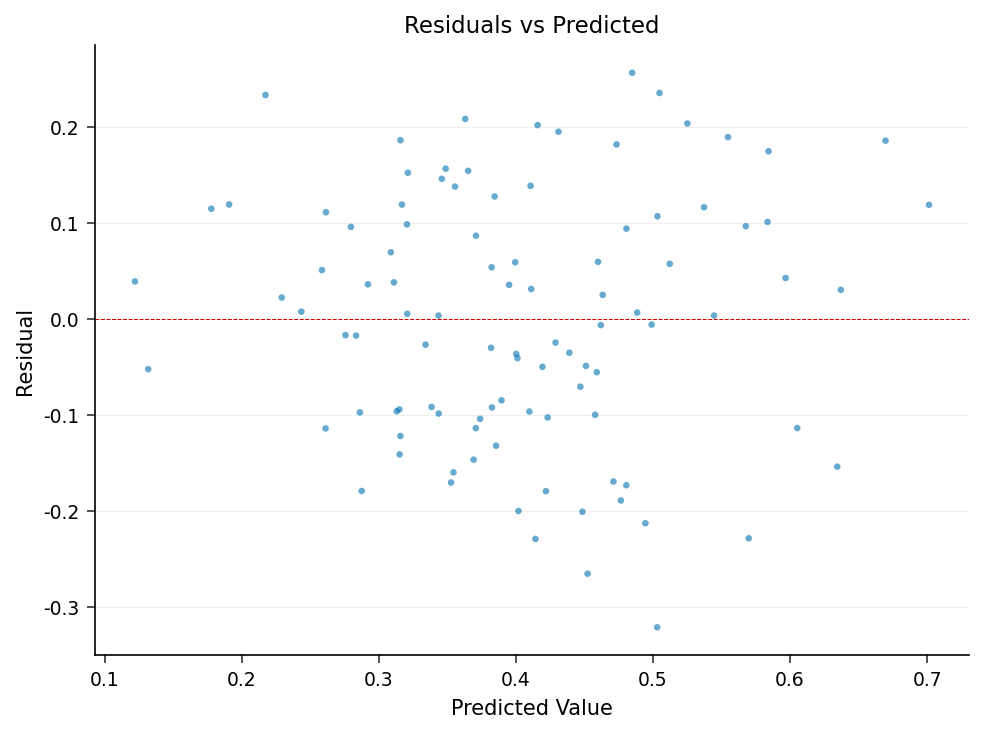

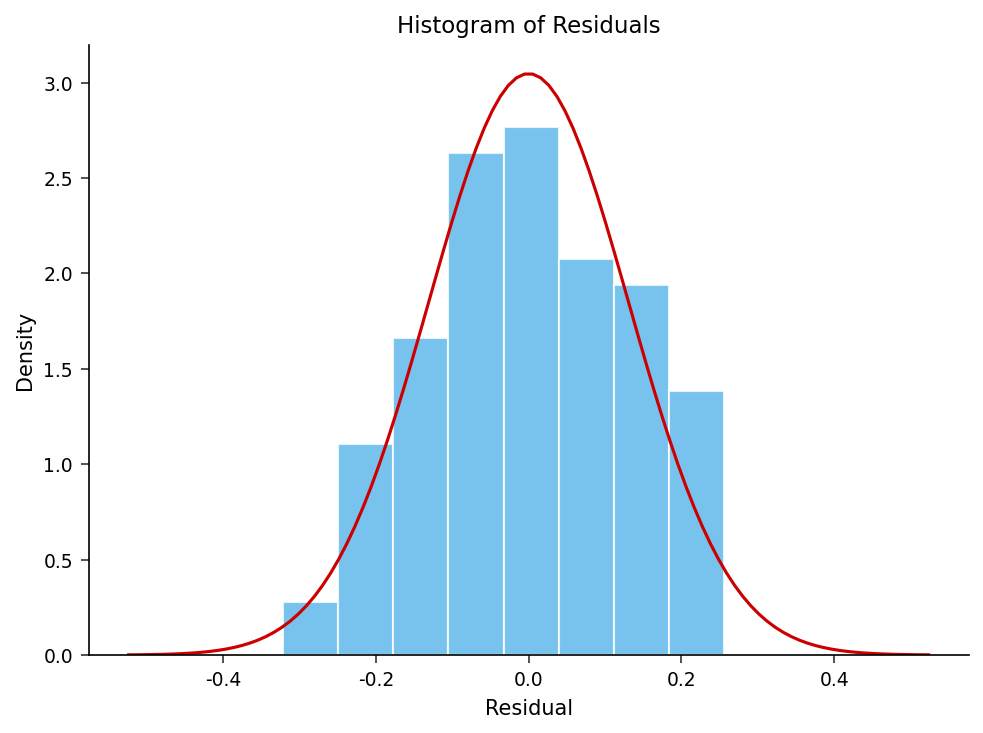

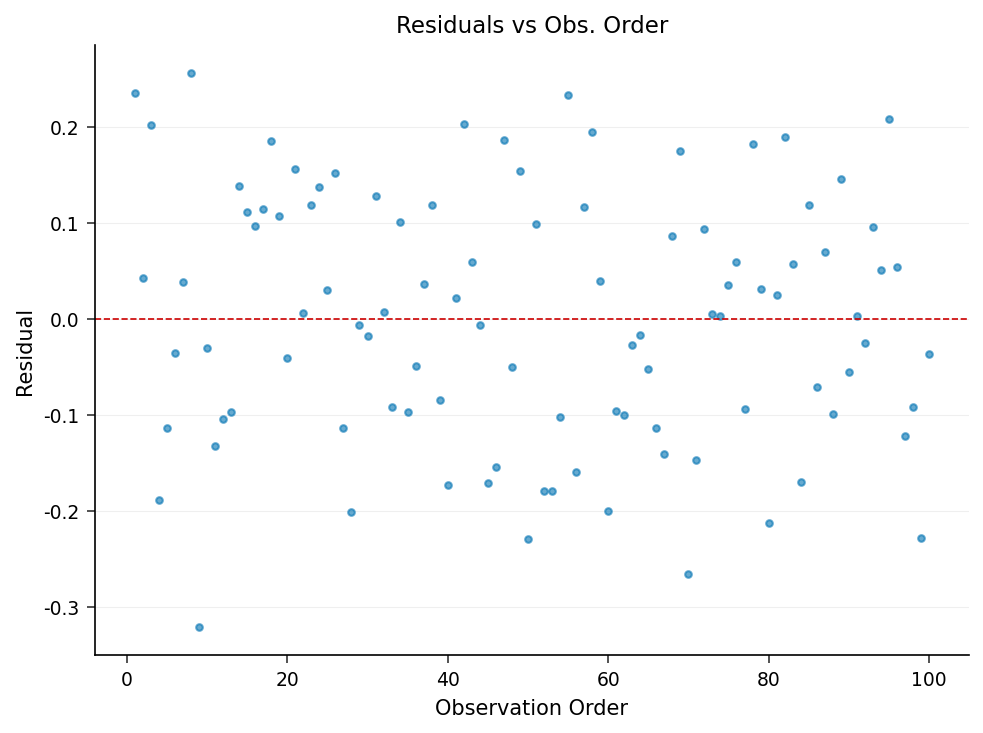

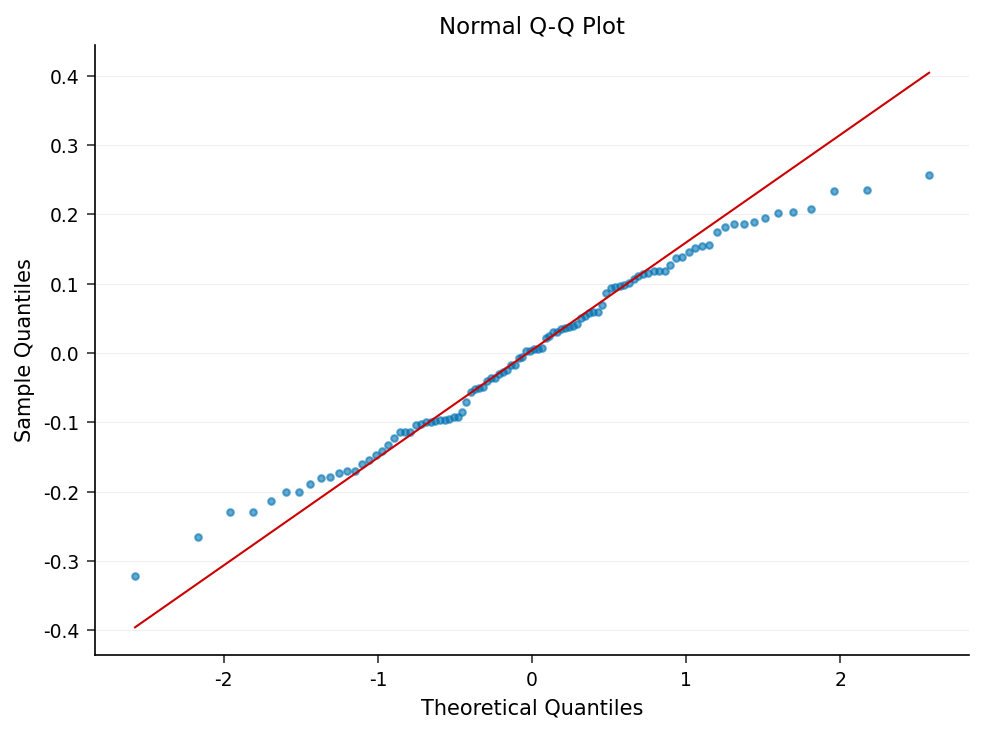

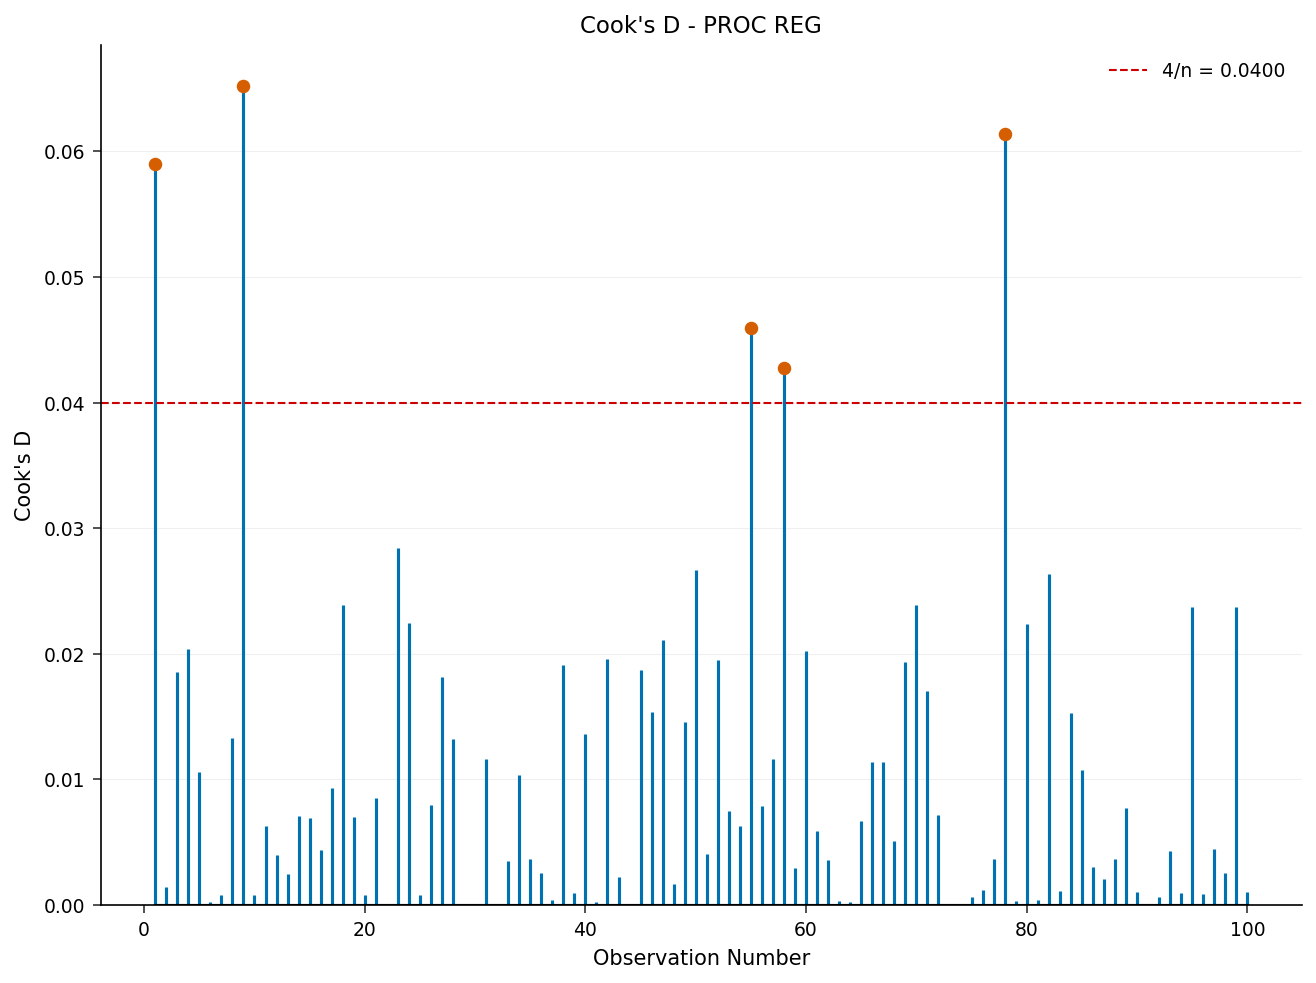

In [3]:
/* Taux d'utilisation vs covariables emprunteur et macro */
PROCÉDURE REG DONNÉES=lignes_credit;
    MODÈLE taux_utilisation =
          csd volatilite_ca util_anterieure
          anciennete_mois taux_chomage taux_court
          / clb stb vif tol;
EXÉCUTER;
QUIT;

## 4. Utilisation par segment sectoriel — modèle linéaire général

Certains secteurs tirent-ils leurs lignes de façon plus agressive une fois pris en compte la qualité de l'emprunteur et le contexte macroéconomique ? **PROC GLM** traite `secteur` comme un effet de classification et ajoute les mêmes covariables continues comme contrôles d'analyse de covariance. Nous demandons :

- **SOLUTION** — les estimations de paramètres pour chaque niveau de secteur par rapport à la référence.
- **LSMEANS / PDIFF / ADJUST=TUKEY / CL** — moyennes des moindres carrés ajustées par Tukey et différences par paires, l'utilisation ajustée sur covariables pour chaque segment.

GLM produit le même panneau de diagnostic ODS que REG, plus un diagramme en barres des moyennes des moindres carrés par secteur (avec intervalles de confiance), présenté sous les tableaux. C'est aussi une procédure de type RUN-group, elle se termine donc par `quit;`.

                            The GLM Procedure                             
  Dependent Variable: taux_utilisation Taux d'utilisation (tiré/limite)  

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
secteur                 4         0.21335      0.05334      3.15    0.0180
csd                     1         0.67988      0.67988     40.15    <.0001
volatilite_ca           1         0.13146      0.13146      7.76    0.0065
util_anterieure         1         0.41883      0.41883     24.73    <.0001
taux_chomage            1         0.13917      0.13917      8.22    0.0052
taux_court              1         0.09471      0.09471      5.59    0.0202
Error                  90         1.52407      0.01693                    

Root MSE           0.13013    R-Square            0.4911
Adj R-Sq            0.4402

                       Parameter Estimates                       

Parameter            E


NOTE: PROC GLM data=lignes_credit

NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: ODS plot written: glm_residuals_vs_predicted.spec.json
NOTE: ODS plot written: glm_residual_histogram_panel.spec.json
NOTE: ODS plot written: glm_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: glm_qq_plot.spec.json
NOTE: ODS plot written: glm_lsmeans_secteur.spec.json
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.


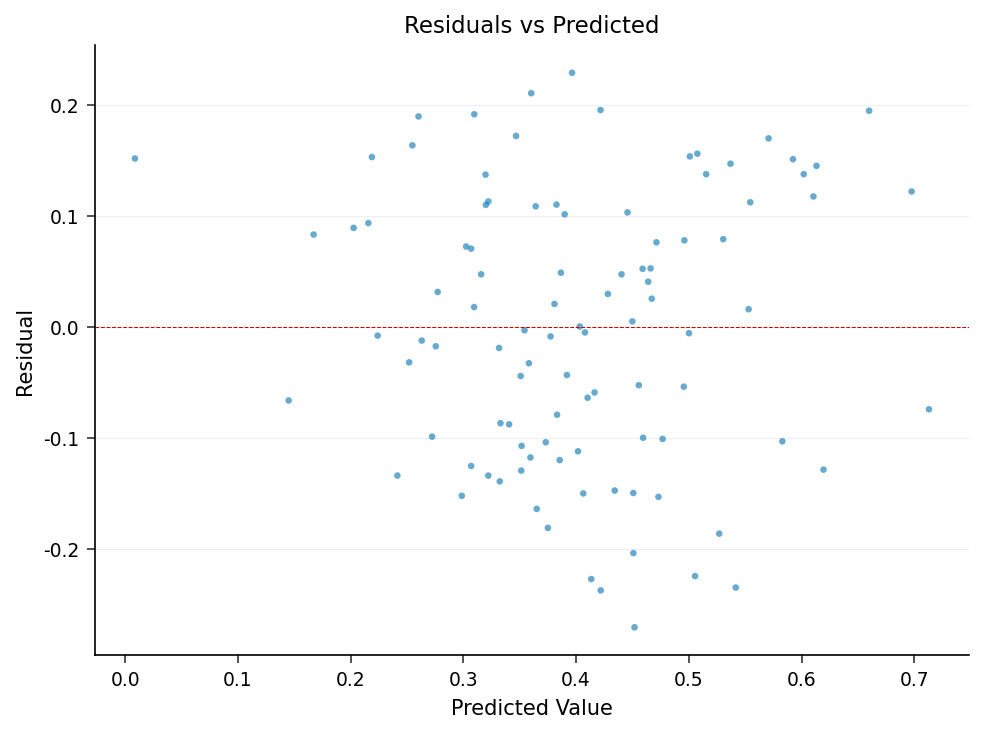

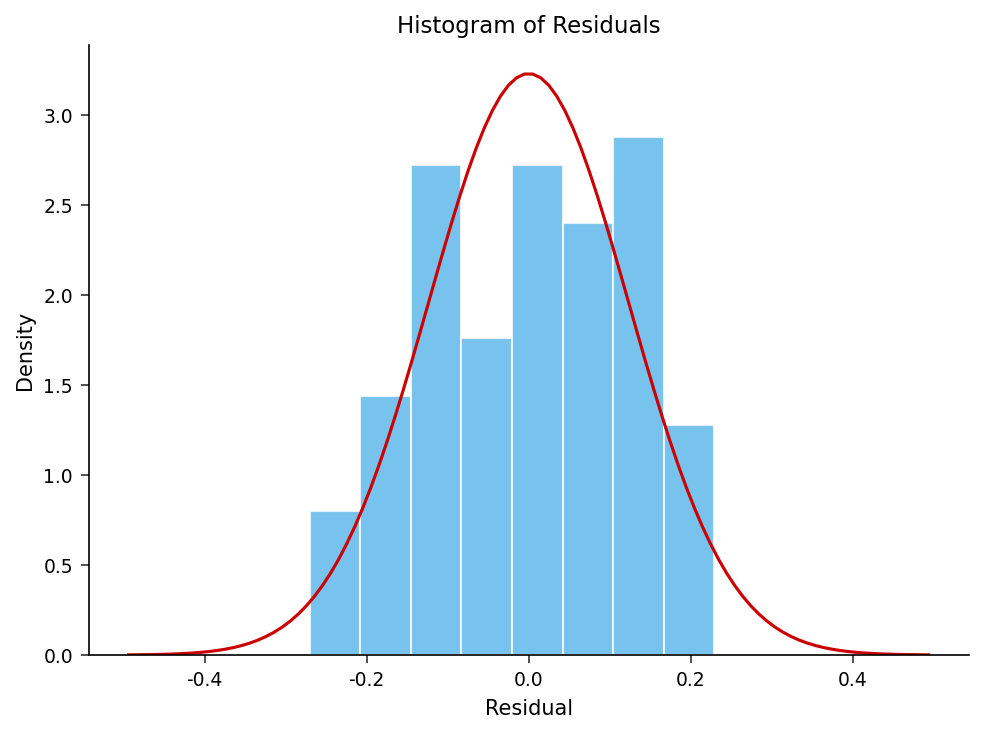

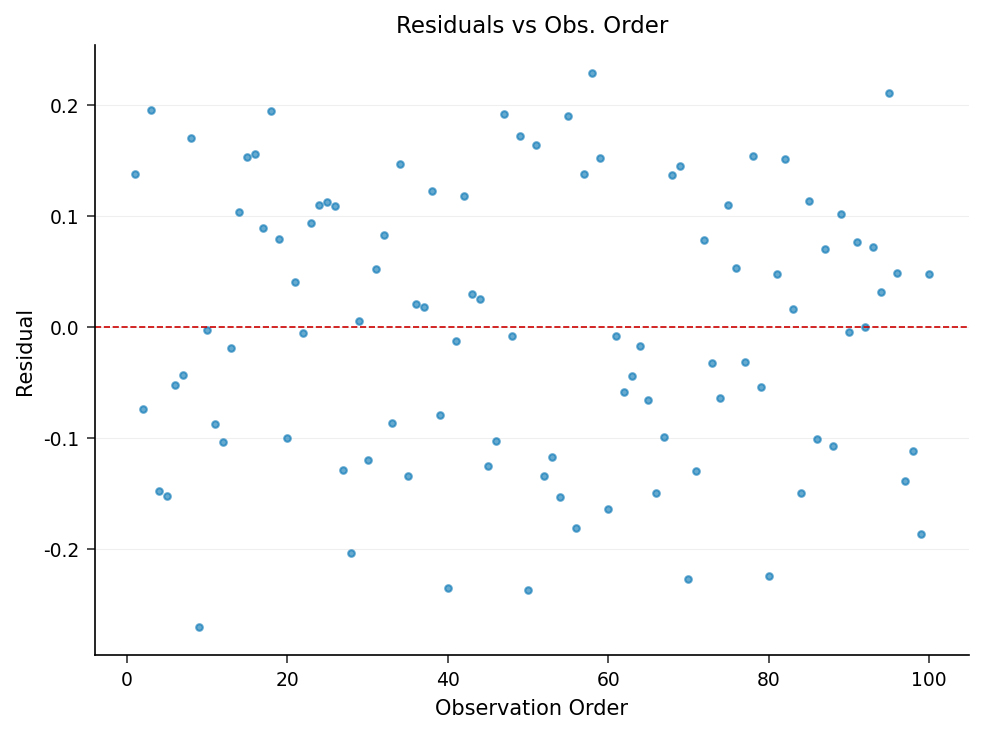

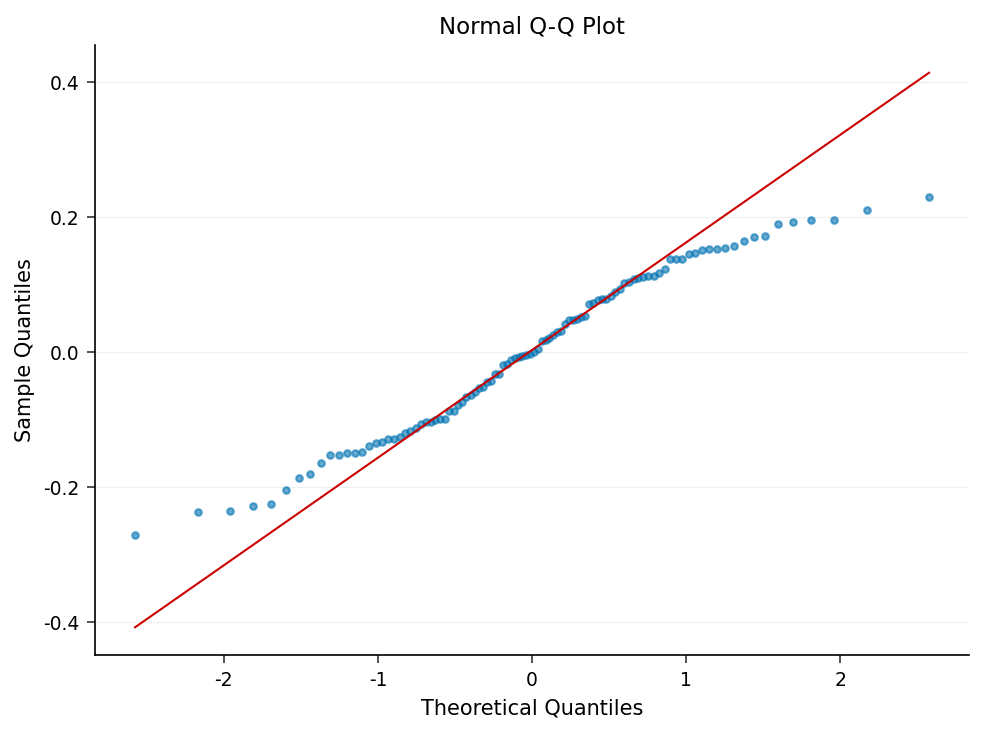

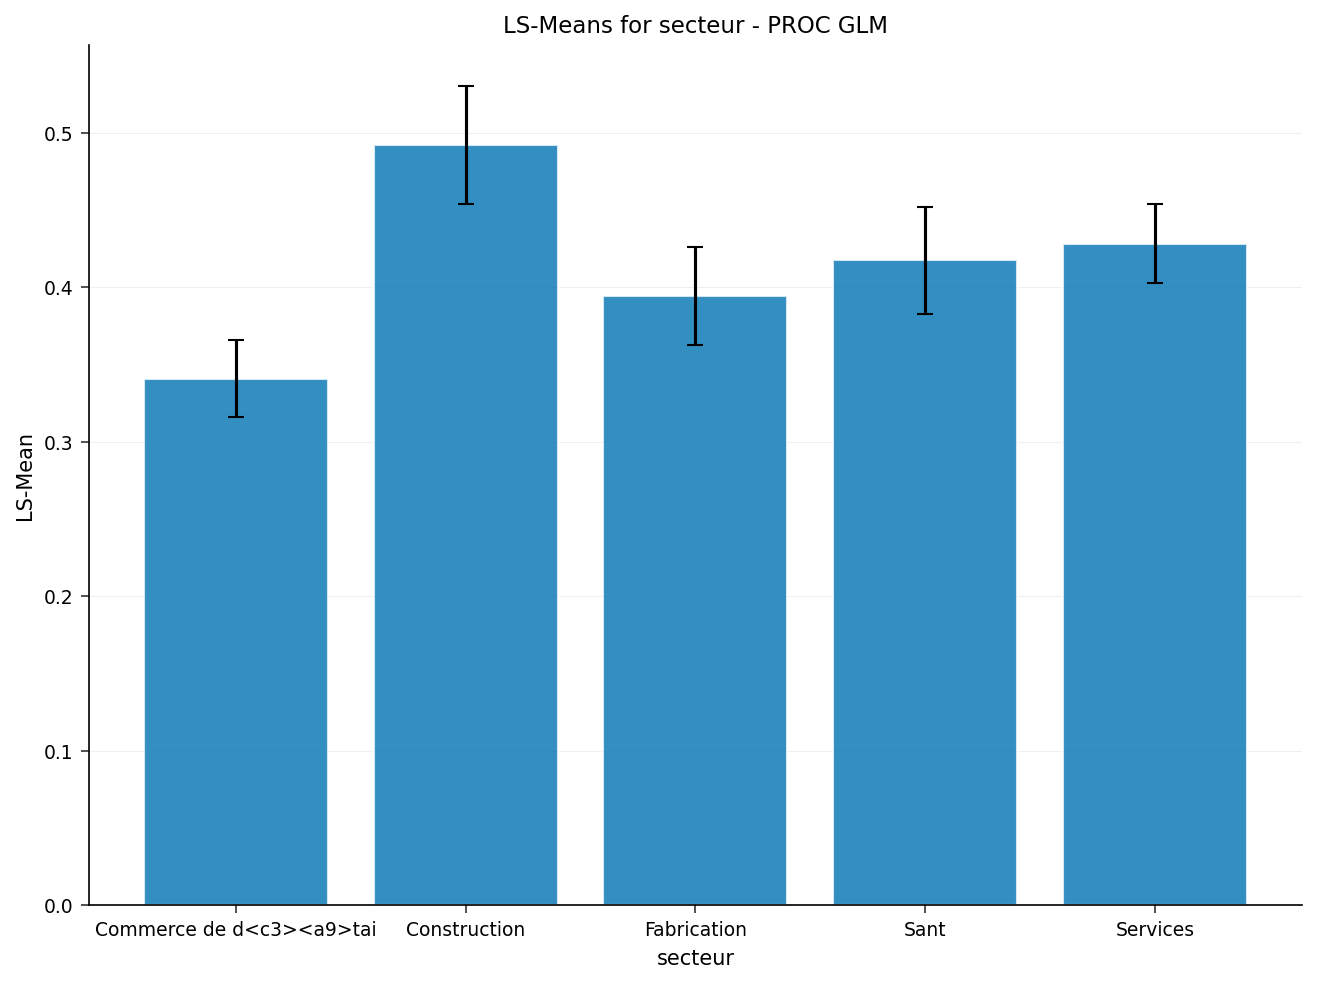

In [4]:
/* Utilisation par segment sectoriel, ajustée des déterminants */
PROCÉDURE MLG DONNÉES=lignes_credit;
    CLASSE secteur;
    MODÈLE taux_utilisation =
          secteur csd volatilite_ca util_anterieure
          taux_chomage taux_court
          / SOLUTION ss3;
    LSMEANS secteur / PDIFF ADJUST=TUKEY cl;
EXÉCUTER;
QUIT;

## 5. Plage d'utilisation pour les tests de résistance et le capital économique

La planification du capital a besoin des **queues** de la distribution d'utilisation, pas seulement de la moyenne. Comme les centiles fractionnaires se prennent mieux avec **PROC UNIVARIATE** qu'avec PROC MEANS, nous utilisons `PCTLPTS=` pour extraire les **2,5e et 97,5e centiles** de l'utilisation. La plage obtenue définit un scénario plausible de tirage faible/élevé pour les tests de résistance du solde financé.

In [5]:
/* Centiles 2,5 / 97,5 de l'utilisation pour la plage de résistance */
PROCÉDURE UNIVARIÉ DONNÉES=lignes_credit SANS_IMPRESSION;
    VAR taux_utilisation;
    SORTIE out=plage_util
           mean=util_moyenne
           pctlpts=2.5 97.5
           pctlpre=util_p
           pctlname=bas haut;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=plage_util noobs ÉTIQUETTE;
    ÉTIQUETTE util_moyenne = "Utilisation moyenne"
          util_pbas  = "2,5e centile (résistance bas)"
          util_phaut = "97,5e centile (résistance haut)";
EXÉCUTER;


Utilisation moyenne   2,5e centile (résistance bas)   97,5e centile (résistance haut)
-------------------  ------------------------------  --------------------------------
             0.4031                          0.1467                            0.7587




NOTE: PROC UNIVARIATE
NOTE: Output dataset plage_util has 1 observations and 3 variables.
NOTE: PROC PRINT data=plage_util

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## 6. Interprétation et prochaines étapes

**Ce que montre le modèle**

- **La classe de risque détermine l'exposition financée.** Le profil PROC MEANS montre que l'utilisation moyenne augmente de façon monotone de la classe la plus solide à la plus faible — 0,307 (A), 0,359 (B), 0,416 (C), 0,488 (D), 0,518 (E). Parce que le solde tiré est l'utilisation multipliée par la limite engagée, les classes plus faibles convertissent une part plus grande de leurs engagements en soldes financés — l'intrant central de l'exposition en cas de défaut et du capital économique des lignes renouvelables. (Le solde tiré moyen augmente aussi avec la classe, culminant à la classe D dans cet échantillon de 100 lignes ; la petite cellule de la classe E, avec 9 lignes, comporte une limite très élevée qui déforme sa moyenne de limite engagée, exactement le type de comportement de petite cellule que le portefeuille complet lisserait.)
- **Les fondamentaux de l'emprunteur dominent la régression.** Dans PROC REG, la **couverture du service de la dette** porte le plus grand coefficient standardisé (-0,45) et est protectrice — chaque unité supplémentaire de couverture abaisse l'utilisation d'environ 0,11 (IC à 95 % -0,152 à -0,075). L'**utilisation antérieure** est le deuxième déterminant le plus fort (standardisé 0,41, estimation +0,38) : les lignes fortement tirées auparavant restent fortement utilisées. La **volatilité du chiffre d'affaires** (+0,37, p = 0,021) et les termes macroéconomiques — le **chômage** (+0,036, p = 0,009) et le **taux court** (+0,036, p = 0,036) — sont tous positifs et significatifs, de sorte qu'un ralentissement relève mécaniquement les soldes financés à l'échelle du portefeuille. Tous les VIF sont inférieurs à 1,17, bien en deçà du seuil conventionnel de 10, confirmant que les déterminants ne sont pas colinéaires, et les intervalles CLB excluent zéro pour chaque effet sauf l'ancienneté de la ligne. Les diagnostics des résidus sont bien conformes : les résidus se dispersent aléatoirement autour de zéro, l'histogramme est approximativement normal et le diagramme Q-Q est proche de la linéarité avec seulement un léger écart dans les queues ; la distance de Cook signale quatre lignes modérément influentes (au-dessus de 4/n = 0,04) qui méritent un examen de la qualité des données.
- **Le secteur ajoute un signal résiduel à la limite de la significativité.** Après contrôle des covariables de l'emprunteur et macroéconomiques, l'effet sectoriel global dans PROC GLM n'est qu'à la limite (F de type III p = 0,060). Mais les moyennes des moindres carrés ajustées par Tukey séparent tout de même les segments : la **Construction** présente l'utilisation ajustée la plus élevée (0,492), suivie des **Services** (0,428), avec la **Fabrication** (0,394), la **Santé** (0,374) et le **Commerce de détail** (0,366) regroupés en dessous. Les tests par paires confirment que la Construction tire nettement plus que le **Commerce de détail** (différence 0,126, p = 0,007) et la **Santé** (0,118, p = 0,024) ; les autres écarts par paires ne sont pas significatifs. Cela concorde avec la façon dont l'intensité en fonds de roulement varie selon le secteur et désigne la Construction comme le segment à surveiller.

**Comment l'utiliser**

- **Prévoir les soldes financés** en appliquant la régression à des trajectoires macroéconomiques prospectives (hausse du chômage, taux courts plus élevés) pour projeter le solde tiré du portefeuille sous chaque scénario.
- **Fixer la plage de résistance du capital économique** à partir des centiles de PROC UNIVARIATE : l'utilisation varie plausiblement de **0,121** (2,5e) à **0,744** (97,5e) autour d'une moyenne de 0,404, dimensionnant le scénario de tirage faible/élevé pour un ralentissement.
- **Différencier les limites et la tarification** par classe de risque et selon le tirage ajusté élevé de la Construction, en facturant l'utilisation attendue plus élevée — et l'exposition financée plus élevée — que quantifient les résultats de MEANS et de GLM.

**Prolongements**

Remplacer le lien MCO par une régression à réponse fractionnaire ou bêta (PROC GLIMMIX / PROC NLMIXED) pour respecter la borne 0–1, ajouter un effet aléatoire d'emprunteur pour les panels multipériodes, et injecter l'utilisation ajustée directement dans un moteur de perte en cas de défaut et de capital économique. Réexécuter sur le portefeuille complet (non plafonné) resserrerait les petites cellules de classe de risque et de secteur et affinerait probablement le test F sectoriel à la limite.